In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# load clean data
# load clean data in — baseline feature set 
CRMLSSold_cleaned = pd.read_csv('../data/cleaned_CRMLSSOLD_baseline.csv')
print(CRMLSSold_cleaned.info())
CRMLSSold_cleaned.head()

<class 'pandas.DataFrame'>
RangeIndex: 79306 entries, 0 to 79305
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CloseDate              79306 non-null  str    
 1   ClosePrice             79306 non-null  float64
 2   LivingArea             79306 non-null  float64
 3   BedroomsTotal          79306 non-null  int64  
 4   BathroomsTotalInteger  79306 non-null  int64  
 5   YearBuilt              79306 non-null  int64  
 6   GarageSpaces           76469 non-null  float64
 7   LotSizeSquareFeet      77911 non-null  float64
 8   CountyOrParish         79306 non-null  str    
 9   Latitude               79306 non-null  float64
 10  Longitude              79306 non-null  float64
 11  PoolPrivateYN          79306 non-null  str    
 12  ViewYN                 79306 non-null  str    
 13  FireplaceYN            79306 non-null  str    
 14  NewConstructionYN      79306 non-null  str    
 15  HasAssociatio

,CloseDate,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,GarageSpaces,LotSizeSquareFeet,CountyOrParish,Latitude,Longitude,PoolPrivateYN,ViewYN,FireplaceYN,NewConstructionYN,HasAssociationFee
0,2025-11-30,1250000.0,1027.0,3,2,1961,2.0,5913.0,Orange,33.676050,-117.995210,False,False,False,False,False
1,2025-11-20,2299995.0,1129.0,3,1,1949,2.0,18432.0,Santa Clara,37.260693,-121.934121,Unknown,False,True,False,Unknown
2,2025-11-26,810000.0,1619.0,4,3,1978,2.0,5300.0,San Diego,32.564997,-117.064393,False,False,True,Unknown,False
3,2025-11-17,925000.0,2872.0,5,3,2000,3.0,5272.0,San Diego,32.575778,-117.024433,False,False,True,Unknown,True
4,2025-11-25,1300000.0,1727.0,3,2,1950,3.0,10500.0,San Luis Obispo,35.553064,-120.708510,False,False,True,False,False


In [2]:
# Same time-based train/test split as 04_model_comparison.ipynb
def make_train_test_split(df, feature_cols, training_months=None):
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])
    df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

    test_month  = df['CloseMonth'].max()
    train_start = test_month - training_months if training_months else df['CloseMonth'].min()

    train = df[(df['CloseMonth'] >= train_start) & (df['CloseMonth'] < test_month)].copy()
    test  = df[df['CloseMonth'] == test_month].copy()

    X_train = train[feature_cols]
    y_train = train['ClosePrice']
    X_test  = test[feature_cols]
    y_test  = test['ClosePrice']

    print(f"Test month:  {test_month}")
    print(f"Train range: {train['CloseMonth'].min()} to {train['CloseMonth'].max()}  ({train['CloseMonth'].nunique()} months)")
    print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

    return X_train, y_train, X_test, y_test

In [3]:
# Base ("old") feature set — same as 04_model_comparison.ipynb
categorical_cols = ['PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'NewConstructionYN',
                    'HasAssociationFee', 'CountyOrParish']
numeric_cols = ['LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger',
                'YearBuilt', 'GarageSpaces', 'Latitude', 'Longitude']
base_feature_cols = [col for col in CRMLSSold_cleaned.columns if col != 'ClosePrice']

# Pull PostalCode/City/MLSAreaMajor from the all-features CSV (row-aligned with CRMLSSold_cleaned)
_all_features_df = pd.read_csv('../data/cleaned_CRMLSSOLD_all_features.csv')
assert len(_all_features_df) == len(CRMLSSold_cleaned), "Row count mismatch between CSVs"
CRMLSSold_cleaned['PostalCode'] = _all_features_df['PostalCode'].astype(str)
CRMLSSold_cleaned['City'] = _all_features_df['City']
CRMLSSold_cleaned['MLSAreaMajor'] = _all_features_df['MLSAreaMajor']

# School district join — same approach as 04_model_comparison.ipynb
import geopandas as gpd

districts = gpd.read_file('../data/ca_school_districts.geojson')[['DistrictName', 'geometry']]

listings = gpd.GeoDataFrame(
    CRMLSSold_cleaned,
    geometry=gpd.points_from_xy(CRMLSSold_cleaned['Longitude'], CRMLSSold_cleaned['Latitude']),
    crs='EPSG:4326'
)

n_before_join = len(listings)
listings = gpd.sjoin(listings, districts, how='left', predicate='within')

# Overlapping district polygons can duplicate a row — keep first match per row
listings = listings[~listings.index.duplicated(keep='first')]
listings = listings.drop(columns=['geometry', 'index_right'])
assert len(listings) == n_before_join, "Row count changed after dedup — join still producing extras"

n_unmatched = listings['DistrictName'].isna().sum()
print(f"Unmatched to a district: {n_unmatched:,} ({n_unmatched / len(listings):.2%})")
listings = listings.dropna(subset=['DistrictName'])

CRMLSSold_cleaned = pd.DataFrame(listings)
print(f"Unique PostalCode: {CRMLSSold_cleaned['PostalCode'].nunique():,}")
print(f"Unique City: {CRMLSSold_cleaned['City'].nunique():,}")
print(f"Unique DistrictName: {CRMLSSold_cleaned['DistrictName'].nunique():,}")
print(f"Unique MLSAreaMajor: {CRMLSSold_cleaned['MLSAreaMajor'].nunique():,}")

# Full feature set: base features + PostalCode + City + DistrictName + MLSAreaMajor
location_cols = ['PostalCode', 'City', 'DistrictName', 'MLSAreaMajor']
feature_cols = base_feature_cols + location_cols

preprocessor = ColumnTransformer([
    ('impute', SimpleImputer(strategy='median'), numeric_cols),
    ('encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('encode_location', OneHotEncoder(handle_unknown='ignore', min_frequency=50), location_cols),
])

CRMLSSold_cleaned['ClosePrice'] = np.log(CRMLSSold_cleaned['ClosePrice'])

X_train, y_train, X_test, y_test = make_train_test_split(
    CRMLSSold_cleaned, feature_cols, training_months=None
)

Unmatched to a district: 5 (0.01%)
Unique PostalCode: 1,295
Unique City: 880
Unique DistrictName: 545
Unique MLSAreaMajor: 963
Test month:  2026-06
Train range: 2025-11 to 2026-05  (7 months)
X_train: (67174, 19)  |  X_test: (12127, 19)


In [4]:
# try gradient boosting such as XGBoost, LightGBM, or CatBoost then compare
from sklearn.pipeline import Pipeline

gb_models = {
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=False),
}

gb_results = {}
for name, model in gb_models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)

    train_preds = pipeline.predict(X_train)
    train_r2 = r2_score(y_train, train_preds)
    train_rmse = mean_squared_error(y_train, train_preds) ** 0.5

    preds = pipeline.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    gb_results[name] = {
        'pipeline': pipeline,
        'Train R^2': train_r2,
        'Test R^2': r2,
        'R^2 Gap (train - test)': train_r2 - r2,
        'Train RMSE (log price)': train_rmse,
        'Test RMSE (log price)': rmse,
    }
    print(f"{name}")
    print(f"  Train R^2:              {train_r2:.4f}")
    print(f"  Test R^2:               {r2:.4f}")
    print(f"  Test RMSE (log price):  {rmse:.4f}")
    print(f"  R^2 gap (train - test): {train_r2 - r2:.4f}\n")

# comparison table
gb_table = pd.DataFrame({
    name: {k: v for k, v in res.items() if k != 'pipeline'}
    for name, res in gb_results.items()
}).T
gb_table.round(4)

XGBoost
  Train R^2:              0.9263
  Test R^2:               0.9109
  Test RMSE (log price):  0.1810
  R^2 gap (train - test): 0.0154

LightGBM
  Train R^2:              0.9099
  Test R^2:               0.9048
  Test RMSE (log price):  0.1872
  R^2 gap (train - test): 0.0052

CatBoost
  Train R^2:              0.9306
  Test R^2:               0.9260
  Test RMSE (log price):  0.1650
  R^2 gap (train - test): 0.0046



,Train R^2,Test R^2,R^2 Gap (train - test),Train RMSE (log price),Test RMSE (log price)
XGBoost,0.9263,0.9109,0.0154,0.1632,0.1810
LightGBM,0.9099,0.9048,0.0052,0.1804,0.1872
CatBoost,0.9306,0.9260,0.0046,0.1584,0.1650


In [5]:
# follow up gradient boosting with light hyperparameter tuning
import itertools

# Carve a validation month (May) out of the training range (Nov-May) so June
# stays untouched as the final test set — same time-respecting split logic as
# make_train_test_split, just applied one month earlier.
tune_df = CRMLSSold_cleaned[CRMLSSold_cleaned['CloseMonth'] < CRMLSSold_cleaned['CloseMonth'].max()].copy()
X_train_tune, y_train_tune, X_val_tune, y_val_tune = make_train_test_split(
    tune_df, feature_cols, training_months=None
)

# First pass (n_estimators/iterations <= 300, depth <= 5) landed worse than
# the untuned defaults for every model — the grid's upper edge kept winning,
# meaning the real optimum was outside the grid. Widened to include the
# models' own defaults (xgb/catboost depth=6, catboost iterations=1000) and beyond.
param_grids = {
    'XGBoost': {'n_estimators': [300, 600, 1000], 'learning_rate': [0.03, 0.05, 0.1], 'max_depth': [4, 6, 8]},
    'LightGBM': {'n_estimators': [300, 600, 1000], 'learning_rate': [0.03, 0.05, 0.1], 'max_depth': [4, 6, 8]},
    'CatBoost': {'iterations': [300, 600, 1000], 'learning_rate': [0.03, 0.05, 0.1], 'depth': [4, 6, 8]},
}
model_classes = {
    'XGBoost': XGBRegressor,
    'LightGBM': LGBMRegressor,
    'CatBoost': CatBoostRegressor,
}
fixed_kwargs = {
    'XGBoost': {'random_state': 42},
    'LightGBM': {'random_state': 42, 'verbose': -1},
    'CatBoost': {'random_state': 42, 'verbose': False},
}

tuning_results = []
best_params = {}
for name, grid in param_grids.items():
    keys = list(grid.keys())
    best_val_r2 = -np.inf
    for combo in itertools.product(*grid.values()):
        params = dict(zip(keys, combo))
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model_classes[name](**params, **fixed_kwargs[name]))
        ])
        pipeline.fit(X_train_tune, y_train_tune)
        val_r2 = r2_score(y_val_tune, pipeline.predict(X_val_tune))

        tuning_results.append({'Model': name, **params, 'Val R^2': val_r2})
        if val_r2 > best_val_r2:
            best_val_r2 = val_r2
            best_params[name] = params

tuning_table = pd.DataFrame(tuning_results).sort_values(['Model', 'Val R^2'], ascending=[True, False])
tuning_table.round(4)

Test month:  2026-05
Train range: 2025-11 to 2026-04  (6 months)
X_train: (55847, 19)  |  X_test: (11327, 19)


,Model,n_estimators,learning_rate,max_depth,Val R^2,iterations,depth
80,CatBoost,NaN,0.10,NaN,0.9324,1000.0,8.0
79,CatBoost,NaN,0.10,NaN,0.9278,1000.0,6.0
71,CatBoost,NaN,0.10,NaN,0.9265,600.0,8.0
77,CatBoost,NaN,0.05,NaN,0.9240,1000.0,8.0
70,CatBoost,NaN,0.10,NaN,0.9190,600.0,6.0
...,...,...,...,...,...,...,...
18,XGBoost,1000.0,0.03,4.0,0.8887,NaN,NaN
1,XGBoost,300.0,0.03,6.0,0.8877,NaN,NaN
9,XGBoost,600.0,0.03,4.0,0.8699,NaN,NaN
3,XGBoost,300.0,0.05,4.0,0.8653,NaN,NaN


In [6]:
# Refit each model's best (by validation R^2) config on the full training
# range (Nov-May), then score once on the untouched June test set
tuned_results = {}
for name, params in best_params.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_classes[name](**params, **fixed_kwargs[name]))
    ])
    pipeline.fit(X_train, y_train)

    train_preds = pipeline.predict(X_train)
    train_r2 = r2_score(y_train, train_preds)
    train_rmse = mean_squared_error(y_train, train_preds) ** 0.5

    preds = pipeline.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    tuned_results[name] = {
        'pipeline': pipeline,
        'Best Params': params,
        'Train R^2': train_r2,
        'Test R^2': r2,
        'R^2 Gap (train - test)': train_r2 - r2,
        'Test RMSE (log price)': rmse,
    }

tuned_table = pd.DataFrame({
    name: {k: v for k, v in res.items() if k != 'pipeline'}
    for name, res in tuned_results.items()
}).T
tuned_table.sort_values('Test R^2', ascending=False)

,Best Params,Train R^2,Test R^2,R^2 Gap (train - test),Test RMSE (log price)
CatBoost,"{'iterations': 1000, 'learning_rate': 0.1, 'de...",0.945524,0.933539,0.011985,0.156363
LightGBM,"{'n_estimators': 1000, 'learning_rate': 0.1, '...",0.949943,0.933303,0.01664,0.15664
XGBoost,"{'n_estimators': 1000, 'learning_rate': 0.1, '...",0.969598,0.932265,0.037333,0.157855


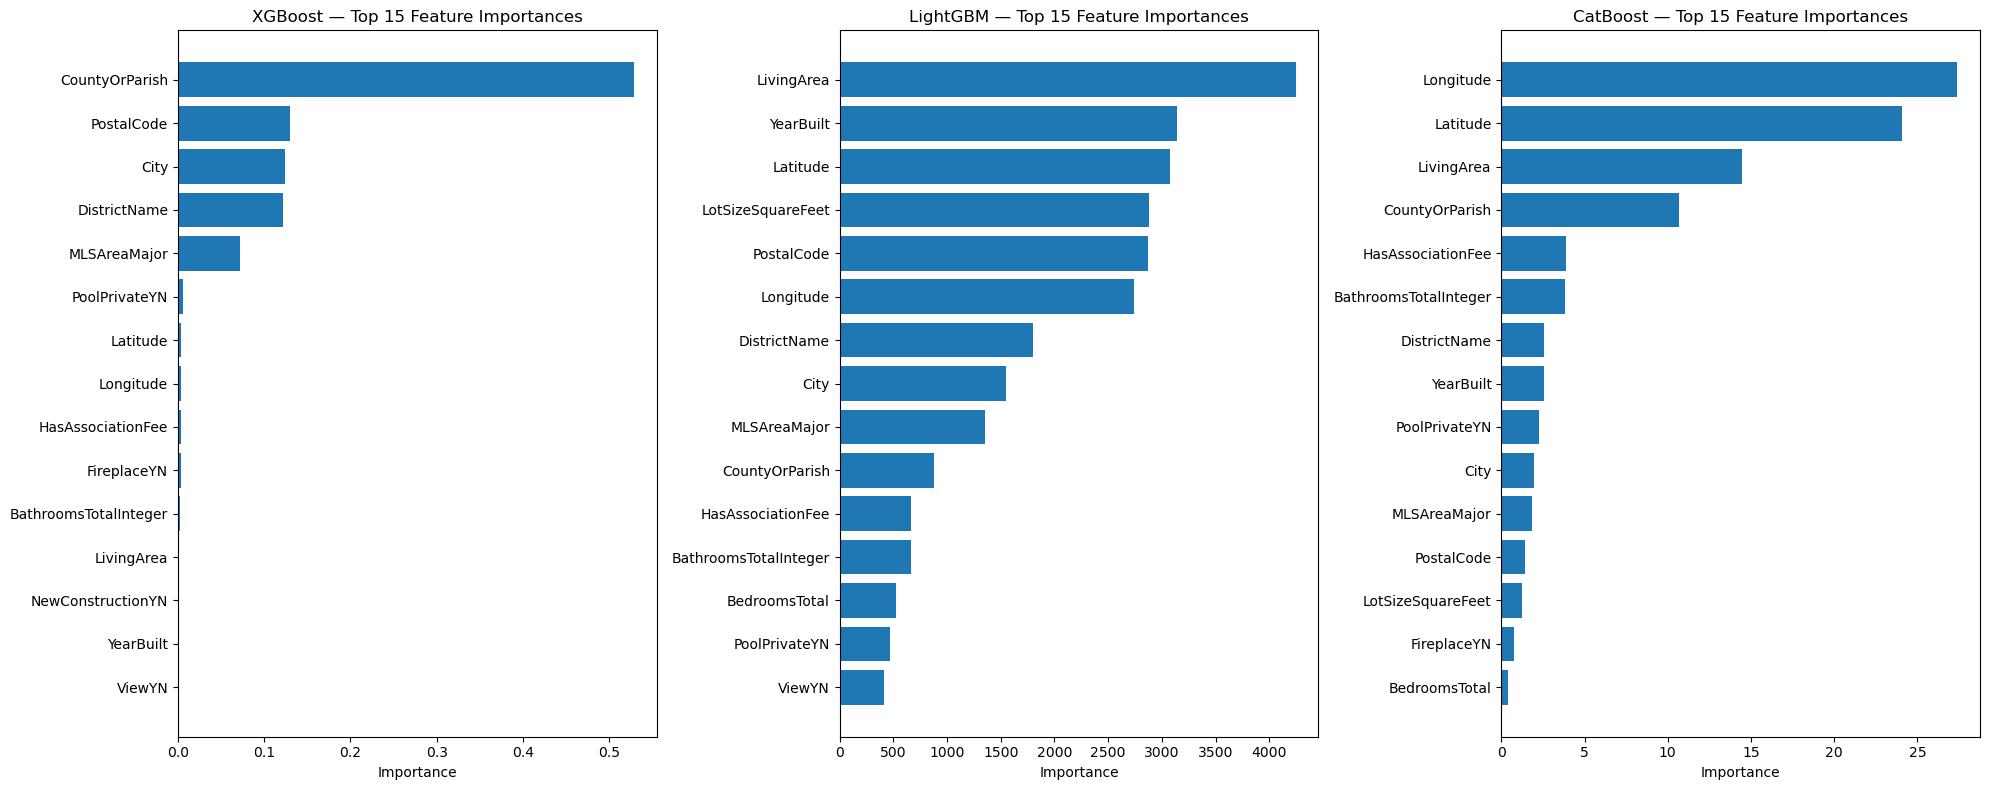

In [9]:
# Feature importance — top 15 base features per tuned model
# (one-hot encoded columns like "CountyOrParish_Orange County" are
# collapsed back into their original feature by summing importances)
base_cols = numeric_cols + categorical_cols + location_cols

def base_feature_of(name):
    stripped = name.split('__', 1)[-1]
    for col in base_cols:
        if stripped == col or stripped.startswith(col + '_'):
            return col
    return stripped

def aggregated_importance(pipeline, top_n=15):
    ct = pipeline.named_steps['preprocessor']
    feature_names = ct.get_feature_names_out()
    importances = pipeline.named_steps['model'].feature_importances_
    grouped = pd.Series(importances, index=[base_feature_of(n) for n in feature_names]).groupby(level=0).sum()
    return grouped.sort_values(ascending=False).head(top_n)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, (name, res) in zip(axes, tuned_results.items()):
    imp_series = aggregated_importance(res['pipeline'])
    ax.barh(imp_series.index[::-1], imp_series.values[::-1])
    ax.set_title(f'{name} — Top 15 Feature Importances')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

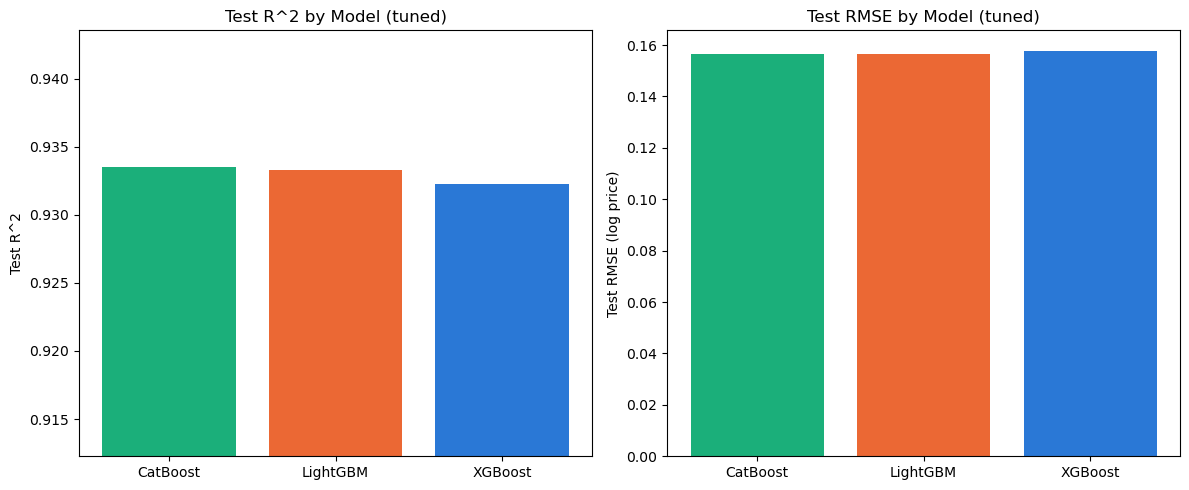

In [10]:
# Plot comparing tuned models — Test R^2 and Test RMSE side by side
plot_df = tuned_table.copy()
plot_df['Test R^2'] = plot_df['Test R^2'].astype(float)
plot_df['Test RMSE (log price)'] = plot_df['Test RMSE (log price)'].astype(float)
plot_df = plot_df.sort_values('Test R^2', ascending=False)

# Fixed color per model (identity, not rank) — validated categorical palette
model_colors = {'XGBoost': '#2a78d6', 'LightGBM': '#eb6834', 'CatBoost': '#1baf7a'}
bar_colors = [model_colors[m] for m in plot_df.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(plot_df.index, plot_df['Test R^2'], color=bar_colors)
axes[0].set_title('Test R^2 by Model (tuned)')
axes[0].set_ylabel('Test R^2')
axes[0].set_ylim(plot_df['Test R^2'].min() - 0.02, plot_df['Test R^2'].max() + 0.01)

axes[1].bar(plot_df.index, plot_df['Test RMSE (log price)'], color=bar_colors)
axes[1].set_title('Test RMSE by Model (tuned)')
axes[1].set_ylabel('Test RMSE (log price)')

plt.tight_layout()
plt.show()